In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from joblib import dump

---
# Load Dataset

In [2]:
df = pd.read_csv('../data/spam_processed.csv')

In [3]:
df.head()

,label,text
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."


---
# Preprocessing

In [4]:
X = df['text']
y = df['label'].map({'ham': 0, 'spam': 1})

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [6]:
tfidf = TfidfVectorizer()

---
# Training Base Model

### Rationale for Evaluation Metrics Selection

Given that our dataset is highly **imbalanced** (with a significantly larger proportion of 'ham' messages compared to 'spam'), evaluating models based solely on **Accuracy** can be highly misleading. A naive model that classifies every message as 'ham' would still yield a high accuracy, while failing completely to detect any spam.

Therefore, our evaluation strategy focuses strictly on the performance metrics of the minority class (**Spam / Class 1**):

1. **Precision (Spam):** This is our **primary critical metric**. It measures the percentage of messages flagged as spam that were actually spam. In a real-world scenario, a False Positive (classifying an important legitimate message or OTP code as spam) is far more detrimental to the user experience than a False Negative. Thus, we must ensure our Precision is exceptionally high.
2. **Recall (Spam):** This measures the proportion of actual spam messages that our model successfully captures. A low recall means more spam leaks into the user's main inbox.
3. **F1-Score (Spam):** Since optimizing Precision and Recall is often a trade-off, we use the F1-Score (the harmonic mean of Precision and Recall for the spam class) as our **ultimate baseline compass** to select and tune the best overall model.

We intentionally avoid using **Weighted Average F1-Score**, as it is heavily influenced by the majority 'ham' class and mask a model's poor performance in detecting actual spam.

In [7]:
def score_calc(cv: dict) -> dict:
    result = dict()
    
    result['accuracy_mean'] = cv['test_accuracy'].mean()
    result['accuracy_std'] = cv['test_accuracy'].std()
    
    result['f1_spam_mean'] = cv['test_f1_spam'].mean()
    result['f1_spam_std'] = cv['test_f1_spam'].std()
    
    result['precision_spam_mean'] = cv['test_precision_spam'].mean()
    result['precision_spam_std'] = cv['test_precision_spam'].std()
    
    result['recall_spam_mean'] = cv['test_recall_spam'].mean()
    result['recall_spam_std'] = cv['test_recall_spam'].std()
    
    return result

In [8]:
def base_model_training(x_data, y_data, tfidf_model, base_model):
    metrics = {
        'accuracy': 'accuracy',
        'f1_spam': 'f1',
        'precision_spam': 'precision',
        'recall_spam': 'recall'
    }
    
    pipe = Pipeline(steps=[
        ('tfidf', tfidf_model),
        ('model', base_model)
    ])
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)
    
    cv = cross_validate(
        estimator=pipe,
        X=x_data,
        y=y_data,
        scoring=metrics,
        cv=skf,
    )
    
    cv_result = score_calc(cv)
    
    return cv_result

In [9]:
models = {
    'naive_bayes': MultinomialNB(),
    'logistic_regression': LogisticRegression(random_state=101, max_iter=1_000_000),
    'svc': SVC(random_state=101, max_iter=1_000_000),
    'xgboost': XGBClassifier(random_state=101, eval_metric='logloss')
}

In [10]:
model_scores = dict()

for name, model in models.items():
    result = base_model_training(X_train, y_train, tfidf, model)
    model_scores[name] = result

In [11]:
scores_df = pd.DataFrame(data=model_scores.values(), index=model_scores.keys())

In [12]:
scores_df.transpose()

,naive_bayes,logistic_regression,svc,xgboost
accuracy_mean,0.950181,0.965659,0.980653,0.969528
accuracy_std,0.002466,0.005276,0.001873,0.002345
f1_spam_mean,0.748044,0.839332,0.915535,0.864663
f1_spam_std,0.014507,0.028534,0.008778,0.012042
precision_spam_mean,1.000000,0.992460,0.995529,0.959704
precision_spam_std,0.000000,0.009753,0.005477,0.008298
recall_spam_mean,0.597716,0.728612,0.847687,0.787150
recall_spam_std,0.018583,0.046322,0.017887,0.022198


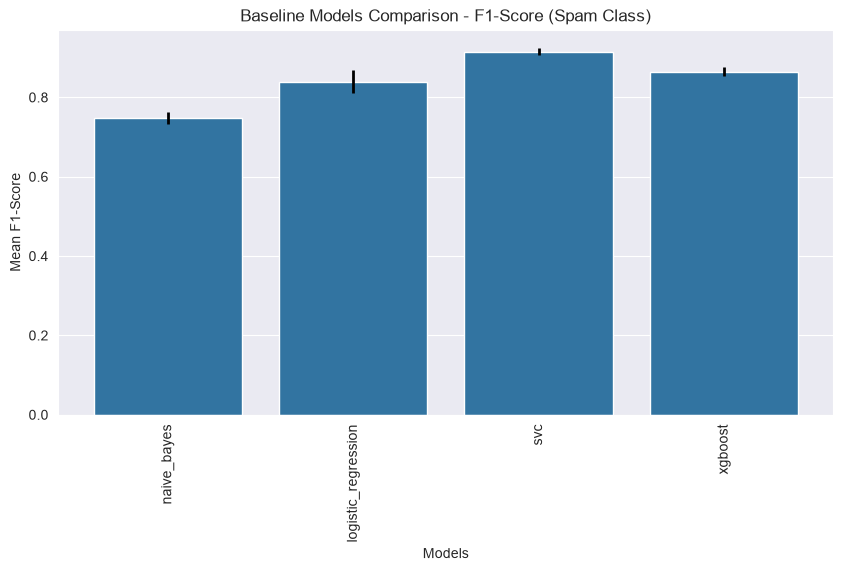

In [13]:
plt.figure(figsize=(10, 5), dpi=100)
sns.barplot(data=scores_df, x=scores_df.index, y='f1_spam_mean')
plt.errorbar(
    x=np.arange(len(scores_df)),
    y=scores_df['f1_spam_mean'],
    yerr=scores_df['f1_spam_std'],
    fmt='none',
    c='black',
    lw=2
)
plt.title("Baseline Models Comparison - F1-Score (Spam Class)")
plt.ylabel("Mean F1-Score")
plt.xlabel("Models")
plt.xticks(rotation=90);

In [14]:
df_melted = scores_df[['precision_spam_mean', 'recall_spam_mean']].reset_index().melt(id_vars='index')

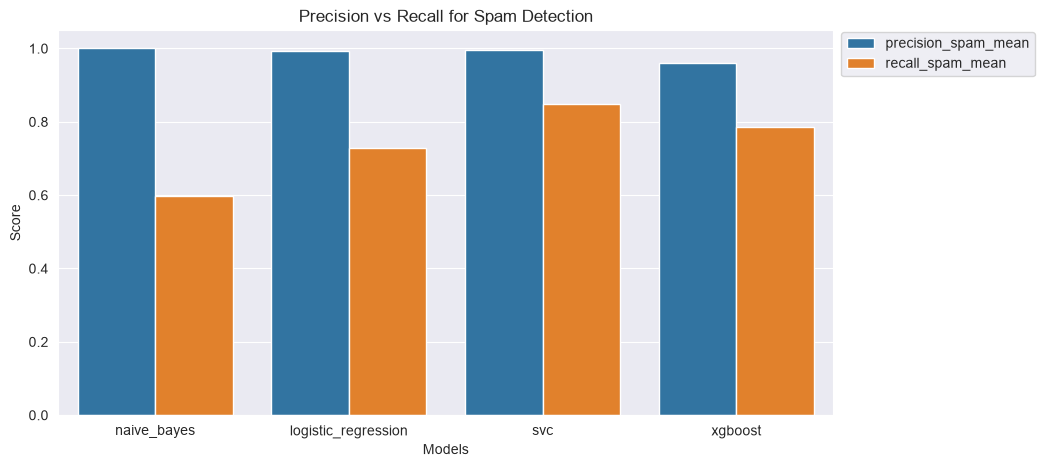

In [15]:
plt.figure(figsize=(10, 5), dpi=100)
sns.barplot(data=df_melted, x='index', y='value', hue='variable')
plt.title("Precision vs Recall for Spam Detection")
plt.ylabel("Score")
plt.xlabel("Models")
plt.legend(loc=(1.01,0.88))
plt.show()

**Considering the score of each model, we find that the SVC model is better than the other models, so we use only the SVR model for the final model and for the tune stage.**

---
# Tune Best Model

In [16]:
best_model = models['svc']

In [17]:
pipeline = Pipeline(steps=[
    ('tfidf', tfidf),
    ('SVC', best_model)
])

In [18]:
grid_params = {
    'tfidf__max_features': [None, 3000, 5000],
    'SVC__kernel': ['linear', 'rbf', 'sigmoid'],
    'SVC__C': np.logspace(-2, 2, 5),
    'SVC__gamma': ['auto', 'scale'],
}

In [19]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)

In [20]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=grid_params,
    scoring='f1',
    cv=skf,
    n_jobs=-1,
    verbose=2
)

In [21]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=101))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'SVC__C': array([1.e-02...e+01, 1.e+02]), 'SVC__gamma': ['auto', 'scale'], 'SVC__kernel': ['linear', 'rbf', ...], 'tfidf__max_features': [None, 3000, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more 

In [22]:
print("Best F1-Score on CV:", grid_search.best_score_)

Best F1-Score on CV: 0.9408667857510574


In [27]:
best_params = grid_search.best_params_

In [28]:
print("Best Parameters Found:", best_params)

Best Parameters Found: {'SVC__C': np.float64(10.0), 'SVC__gamma': 'auto', 'SVC__kernel': 'linear', 'tfidf__max_features': None}


---
# Evaluation Best Model

In [24]:
predict = grid_search.predict(X_test)

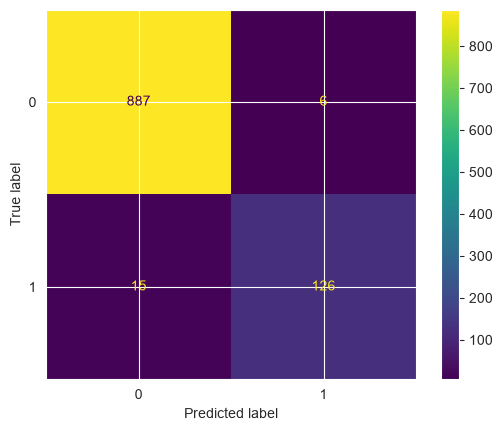

In [25]:
ConfusionMatrixDisplay.from_estimator(
    estimator=grid_search.best_estimator_,
    X=X_test,
    y=y_test,
);

In [26]:
print(classification_report(y_test, predict))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       893
           1       0.95      0.89      0.92       141

    accuracy                           0.98      1034
   macro avg       0.97      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



---
# Final Model Training

In [29]:
final_tfidf = TfidfVectorizer()

In [30]:
final_svc = SVC(
    kernel=best_params['SVC__kernel'],
    C=best_params['SVC__C'],
    gamma=best_params['SVC__gamma'],
    random_state=101
)

In [31]:
final_pipe = Pipeline(steps=[
    ('tfidf', final_tfidf),
    ('SVC', final_svc)
])

In [32]:
final_pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('SVC', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True


In [34]:
dump(final_pipe, '../final_model/spam_detector_model.pkl')

['../final_model/spam_detector_model.pkl']